# Figure 6: QC Covariate Impact Views (quality effects)

- **Panel A:** Winner-take-all bar plot (count of bundle-metric combinations for which each IQM has the largest quality effect). Bars shown only for IQMs with at least two wins; legend order follows bar order (top to bottom).
- **Panel B:** Representative plot of preprocessed dMRI contrast vs FA in the right fornix (GAMM fit, adjusted for age, sex, batch).
- **Panel C:** Cold-scale heatmap of bundle-wise quality effect sizes for preprocessed dMRI contrast across microstructural metrics.
- **Panel D:** Scatter of manual mean rating vs preprocessed dMRI contrast (raw values), colored by vendor, with marginal densities.
- **Panel E:** Violin plot of contrast-vs-mean-rating quality-effect differences in pooled manual-rated data.



## Shared Setup

Libraries, config, plot style, figure directory, theme, and IQM/metric helpers.


In [1]:
# --- Libraries ---
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(forcats)
  library(fs)
  library(jsonlite)
  library(readr)
  library(stringr)
  library(purrr)
  library(scales)
  library(patchwork)
  library(grid)
})
if (requireNamespace("ggpattern", quietly = TRUE)) library(ggpattern)

# --- Config and project paths ---
find_config_path <- function() {
  env_path <- Sys.getenv("CONFIG_PATH", unset = "")
  if (nzchar(env_path) && file.exists(env_path)) {
    return(normalizePath(env_path, winslash = "/", mustWork = TRUE))
  }

  d <- normalizePath(getwd(), winslash = "/", mustWork = TRUE)
  repeat {
    cand <- file.path(d, "config.json")
    if (file.exists(cand)) {
      return(normalizePath(cand, winslash = "/", mustWork = TRUE))
    }
    parent <- dirname(d)
    if (identical(parent, d)) break
    d <- parent
  }

  stop("Could not locate config.json. Set CONFIG_PATH or launch Jupyter from within the project tree.")
}

config_path <- find_config_path()
config <- jsonlite::fromJSON(config_path)
project_root <- normalizePath(config$project_root, winslash = "/", mustWork = FALSE)
plot_style_file <- fs::path(project_root, "scripts", "utils", "plot_style.R")
if (!file.exists(plot_style_file)) stop("Missing plot style helper: ", plot_style_file)
source(plot_style_file)
plot_style <- get_plot_style(config)
plot_style$axis_line_width <- 0.35
plot_style$axis_tick_width <- 0.35
figure6_dir <- fs::path(project_root, "figures", "Figure6")
figure6_panels_dir <- fs::path(figure6_dir, "panels")
fs::dir_create(figure6_panels_dir, recurse = TRUE)
font_family_use <- get_export_font_family()

# --- Panel theme helper (uses plot_style + font) ---
make_panel_theme <- function(legend_position = "none") {
  make_theme_pub(
    style = plot_style,
    legend_position = legend_position,
    axis_title_pt = 6,
    axis_text_pt = 5,
    plot_title_pt = 7,
    legend_title_pt = 5,
    legend_text_pt = 5,
    base_size_pt = 10
  ) +
    theme(text = element_text(family = font_family_use))
}
# save_plot_outputs from plot_style.R (panel out_dir = figure6_panels_dir)

# --- Microstructural metrics and display labels ---
metrics_keep <- c("DKI_mkt", "NODDI_icvf", "MAPMRI_rtop", "GQI_fa", "GQI_md")
metric_labels <- c(
  "DKI_mkt" = "MKT",
  "NODDI_icvf" = "ICVF",
  "MAPMRI_rtop" = "RTOP",
  "GQI_fa" = "FA",
  "GQI_md" = "MD"
)
metric_order <- c("MKT", "ICVF", "RTOP", "FA", "MD")

# --- IQM (image quality metric) list and family/display helpers ---
iqm_metrics <- c(
  "raw_neighbor_corr", "raw_masked_neighbor_corr",
  "raw_dwi_contrast", "raw_num_bad_slices",
  "raw_coherence_index", "raw_incoherence_index",
  "t1_neighbor_corr", "t1_masked_neighbor_corr",
  "t1_dwi_contrast", "t1_num_bad_slices",
  "t1_coherence_index", "t1_incoherence_index",
  "t1post_neighbor_corr", "t1post_masked_neighbor_corr",
  "t1post_dwi_contrast", "t1post_num_bad_slices",
  "t1post_coherence_index", "t1post_incoherence_index",
  "mean_fd", "max_fd", "max_rotation", "max_translation",
  "max_rel_rotation", "max_rel_translation", "t1_dice_distance",
  "CNR0_mean", "CNR1_mean", "CNR2_mean", "CNR3_mean", "CNR4_mean",
  "CNR0_median", "CNR1_median", "CNR2_median", "CNR3_median", "CNR4_median",
  "CNR0_standard_deviation", "CNR1_standard_deviation", "CNR2_standard_deviation",
  "CNR3_standard_deviation", "CNR4_standard_deviation", "qc_prediction"
)
motion_iqms <- c(
  "mean_fd", "max_fd", "max_rotation", "max_translation",
  "max_rel_rotation", "max_rel_translation"
)
classify_family <- function(iqm) {
  if (iqm == "qc_prediction") return("Quality Classifier")
  if (iqm == "t1_dice_distance") return("Coregistration")
  if (iqm %in% motion_iqms) return("Motion")
  if (str_detect(iqm, "^CNR[0-4]_")) return("tSNR/CNR")
  if (str_detect(iqm, "neighbor_corr")) return("dMRI Neighboring Corr.")
  if (str_detect(iqm, "dwi_contrast")) return("dMRI Contrast")
  if (str_detect(iqm, "num_bad_slices")) return("Bad Slices")
  if (str_detect(iqm, "coherence_index") || str_detect(iqm, "incoherence_index")) return("Coherence/Incoherence")
  "Other"
}

cnr_shell_label <- function(shell_id) {
  switch(
    shell_id,
    "0" = "tSNR (b=0)",
    "1" = "CNR (b=500)",
    "2" = "CNR (b=1000)",
    "3" = "CNR (b=2000)",
    "4" = "CNR (b=3000)",
    "CNR"
  )
}

format_iqm_label <- function(iqm) {
  if (iqm == "qc_prediction") return("Quality Classifier Score")
  if (iqm == "t1_dice_distance") return("dMRI-T1w Coregistration")
  if (iqm %in% c("mean_fd", "max_fd", "max_rotation", "max_translation", "max_rel_rotation", "max_rel_translation")) {
    name_map <- c(
      "mean_fd" = "Mean Framewise Displacement",
      "max_fd" = "Max Framewise Displacement",
      "max_rotation" = "Max Rotation",
      "max_translation" = "Max Translation",
      "max_rel_rotation" = "Max Relative Rotation (Derivative)",
      "max_rel_translation" = "Max Relative Translation (Derivative)"
    )
    return(unname(name_map[[iqm]]))
  }
  if (str_detect(iqm, "^CNR[0-4]_(mean|median|standard_deviation)$")) {
    shell_id <- str_match(iqm, "^CNR([0-4])_")[, 2]
    stat <- str_match(iqm, "^(?:CNR[0-4]_)(mean|median|standard_deviation)$")[, 2]
    stat_label <- recode(stat, mean = "Mean", median = "Median", standard_deviation = "SD")
    return(paste(cnr_shell_label(shell_id), stat_label))
  }
  prefix <- case_when(
    str_starts(iqm, "raw_") ~ "Raw",
    str_starts(iqm, "t1post_") ~ "Preprocessed (post-B1)",
    str_starts(iqm, "t1_") ~ "Preprocessed (pre-B1)",
    TRUE ~ ""
  )
  base <- iqm %>%
    str_remove("^raw_") %>%
    str_remove("^t1post_") %>%
    str_remove("^t1_")
  is_masked <- str_starts(base, "masked_")
  core_base <- if (is_masked) str_remove(base, "^masked_") else base
  base_label <- case_when(
    core_base == "neighbor_corr" ~ "Neighboring dMRI Correlation",
    core_base == "dwi_contrast" ~ "dMRI Contrast",
    core_base == "num_bad_slices" ~ "Number of Bad Slices",
    core_base == "coherence_index" ~ "Coherence Index",
    core_base == "incoherence_index" ~ "Incoherence Index",
    TRUE ~ core_base
  )
  qualifier_parts <- character(0)
  if (nzchar(prefix)) {
    q <- prefix %>%
      str_replace("Preprocessed \\(post-B1\\)", "Preprocessed, post-B1") %>%
      str_replace("Preprocessed \\(pre-B1\\)", "Preprocessed, pre-B1")
    qualifier_parts <- c(qualifier_parts, q)
  }
  if (is_masked) qualifier_parts <- c(qualifier_parts, "Masked")
  if (length(qualifier_parts) > 0) {
    paste0(base_label, " (", paste(qualifier_parts, collapse = ", "), ")")
  } else {
    base_label
  }
}
family_order <- c(
  "dMRI Neighboring Corr.",
  "dMRI Contrast",
  "Coherence/Incoherence",
  "Bad Slices",
  "Motion",
  "tSNR/CNR",
  "Coregistration",
  "Quality Classifier"
)
family_colors <- c(
  "dMRI Neighboring Corr." = "#1b9e77",
  "dMRI Contrast" = "#d95f02",
  "Coherence/Incoherence" = "#7570b3",
  "Bad Slices" = "#e7298a",
  "Motion" = "#66a61e",
  "tSNR/CNR" = "#e6ab02",
  "Coregistration" = "#a6761d",
  "Quality Classifier" = "black"
)
# Build lookup: iqm -> pretty label and family for bar chart
iqm_dict <- tibble(iqm = iqm_metrics) %>%
  mutate(
    iqm_label = map_chr(iqm, format_iqm_label),
    family = factor(map_chr(iqm, classify_family), levels = family_order)
  )
# --- Load quality-effect data ---
# Use real quality effects from scripts/5_quality_effects (quality_effects_all_outputs.rds).
# Set USE_AGE_EFFECTS_QC <- TRUE only to test qc_effect_size derived from age_effects.
USE_AGE_EFFECTS_QC <- FALSE
if (USE_AGE_EFFECTS_QC) {
  age_effect_file <- fs::path(project_root, "data", "age_effects", "age_effects_all_outputs.rds")
  if (!file.exists(age_effect_file)) stop("Missing age-effects file (USE_AGE_EFFECTS_QC=TRUE): ", age_effect_file)
  df_quality_all <- readRDS(age_effect_file)
  if (!"qc_effect_size" %in% names(df_quality_all)) stop("age_effects RDS missing qc_effect_size. Run add_qc_effect_from_age_effects.R first.")
  df_qc_all <- df_quality_all %>%
    filter(
      output_type == "pooled",
      source == "harmonized",
      metric %in% metrics_keep,
      qc_metric %in% iqm_metrics,
      qc_metric != "no_quality",
      !is.na(bundle),
      !is.na(bundle_category),
      !is.na(qc_metric),
      !is.na(qc_effect_size)
    ) %>%
    transmute(
      bundle = bundle,
      bundle_category = bundle_category,
      metric = metric,
      metric_label = unname(metric_labels[metric]),
iqm = qc_metric,
        qc_effect_size = as.numeric(qc_effect_size)
      )
  message("[Figure 6] Using QC effect from age_effects (qc_effect_size = R2 full - R2(s(age)+sex))")
} else {
  quality_effect_file <- fs::path(project_root, "data", "quality_effects", "quality_effects_all_outputs.rds")
  if (!file.exists(quality_effect_file)) stop("Missing assembled quality-effect file: ", quality_effect_file)
  df_quality_all <- readRDS(quality_effect_file)
  required_qc_cols <- c(
    "bundle", "bundle_category", "metric", "qc_metric", "source",
    "output_type", "qc_effect_size", "scanner_manufacturer"
  )
  if (!all(required_qc_cols %in% names(df_quality_all))) {
    stop("Assembled quality-effect data missing required columns: ",
         paste(setdiff(required_qc_cols, names(df_quality_all)), collapse = ", "))
  }
  df_qc_all <- df_quality_all %>%
    filter(
      output_type == "non_vendorwise_pairwise",
      source == "harmonized",
      metric %in% metrics_keep,
      qc_metric %in% iqm_metrics,
      !is.na(bundle),
      !is.na(bundle_category),
      !is.na(qc_metric),
      !is.na(qc_effect_size)
    ) %>%
    transmute(
      bundle = bundle,
      bundle_category = bundle_category,
      metric = metric,
      metric_label = unname(metric_labels[metric]),
      iqm = qc_metric,
      qc_effect_size = as.numeric(qc_effect_size)
    )
}
if (nrow(df_qc_all) == 0) {
  stop("No rows found for Figure 6 pooled quality-effects with requested IQMs.")
}



## Panel A: Winner-take-all bar chart

For each bundle–metric cell, which IQM had the largest (absolute) QC effect? Bar chart of win counts by IQM family.


In [ ]:
# --- Winner-take-all: for each bundle–metric cell, which IQM had largest |QC effect|? ---
wta_counts <- df_qc_all %>%
  arrange(metric, bundle, iqm) %>%
  group_by(metric, bundle) %>%
  slice_max(order_by = qc_effect_size, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  count(iqm, name = "n_wins") %>%
  right_join(tibble(iqm = iqm_metrics), by = "iqm") %>%
  mutate(n_wins = replace_na(n_wins, 0L)) %>%
  left_join(iqm_dict, by = "iqm") %>%
  arrange(desc(n_wins), iqm)
readr::write_csv(wta_counts, fs::path(figure6_dir, "Figure6_winner_take_all_counts.csv"))
# Reshape for bar chart: n_wins per IQM family, ordered for display (≥2 wins only)
wta_counts_plot <- wta_counts %>%
  filter(n_wins >= 2) %>%
  mutate(iqm_label = forcats::fct_reorder(iqm_label, n_wins, .desc = TRUE)) %>%
  arrange(desc(n_wins))
# Legend fill order: unique families in top-to-bottom bar order (coord_flip + fct_rev)
wta_bar_tbl <- wta_counts_plot %>% distinct(iqm_label, family, n_wins)
bar_iqm_levels <- levels(wta_bar_tbl$iqm_label)
fam_legend_order <- unique(
  as.character(wta_bar_tbl$family)[match(as.character(bar_iqm_levels), as.character(wta_bar_tbl$iqm_label))]
)
wta_counts_plot <- wta_counts_plot %>%
  mutate(family = factor(as.character(family), levels = fam_legend_order))
# Bar chart: win count by IQM family (Panel A)
p_panel_a <- wta_counts_plot %>%
  ggplot(aes(x = forcats::fct_rev(iqm_label), y = n_wins, fill = family)) +
  geom_col(width = 0.84) +
  geom_text(aes(label = n_wins), hjust = -0.12, size = 1.7, family = font_family_use) +
  scale_fill_manual(values = family_colors, breaks = fam_legend_order, drop = TRUE) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
  scale_x_discrete(expand = expansion(add = c(0.10, 0.10))) +
  coord_flip(clip = "off") +
  labs(
    title = NULL,
    x = NULL,
    y = "Count of Max Quality Effect Sizes",
    fill = "IQM Family"
  ) +
  make_panel_theme(legend_position = "none") +
  theme(
    panel.grid = element_blank(),
    plot.margin = margin(4, 4, 2, 4),
    axis.text.x = element_text(size = 5, color = "black"),
    axis.text.y = element_text(angle = 0, hjust = 1, vjust = 0.5, size = 5, color = "black"),
    legend.position = c(0.985, 0.35),
    legend.justification = c(1, 0),
    legend.direction = "vertical",
    legend.background = element_rect(fill = scales::alpha("white", 0.70), color = NA),
    legend.title = element_text(size = 6),
    legend.text = element_text(size = 6),
    legend.spacing.y = unit(0.4, "pt"),
    legend.key.height = unit(6, "pt"),
    legend.key.width = unit(6, "pt")
  )
pair_defs <- tibble::tribble(
  ~pair_label, ~vendor_x, ~vendor_y, ~line_type,
  "GE-Philips", "GE", "Philips", "dotdash",
  "Siemens-GE", "Siemens", "GE", "solid",
  "Siemens-Philips", "Siemens", "Philips", "dotted"
)
compute_pair_rho <- function(dat, vx, vy) {
  d <- dat %>% select(all_of(c(vx, vy))) %>% tidyr::drop_na()
  if (nrow(d) < 3) return(NA_real_)
  cor(d[[vx]], d[[vy]], method = "spearman")
}
prettify_bundle <- function(bundle_name) {
  bundle_name %>%
    str_replace("FrontoOccipital", "Fronto-Occipital") %>%
    str_replace("NonDecussating", "Non-Decussating") %>%
    str_replace("L$", " (L)") %>%
    str_replace("R$", " (R)") %>%
    str_replace_all("(?<=[a-z])(?=[A-Z])", " ")
}
category_order <- c(
  "Association",
  "Projection (Basal Ganglia)",
  "Projection (Brainstem)",
  "Cerebellum",
  "Corpus Callosum"
)
qc_targets <- c("t1post_dwi_contrast")
qc_target_titles <- c(
  "t1post_dwi_contrast" = "Preprocessed dMRI Contrast",
  "t1post_neighbor_corr" = "Preprocessed Neighboring dMRI Correlation"
)
# Combined figure width 180 mm; heatmap shorter so grid aspect matches Figure 3/4 (wider, less tall)
figure_width_mm <- 180
figure_width_in <- figure_width_mm / 25.4
panel_width_mm <- 88
panel_height_in <- (panel_width_mm / 25.4) * 0.96
heatmap_height_scale <- 0.47
heat_height_in <- panel_height_in * heatmap_height_scale
panel_c_export_height_in <- 4
top_row_height_in <- 3.35
figure_height_in <- top_row_height_in + heat_height_in
save_plot_outputs(p_panel_a, "Figure6_panel_a_winner_take_all", figure6_panels_dir, figure_width_in * 0.56, top_row_height_in)


[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure6/panels/Figure6_panel_a_winner_take_all.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure6/panels/Figure6_panel_a_winner_take_all.png



## Panels B & C (per QC target): QC scatter and quality heatmap

For each QC covariate: Panel B shows QC vs highlighted bundle–metric outcome (GAMM-derived curve); Panel C shows heatmap of QC effect sizes. Combined layout saved per target.


[INFO] Figure6 max QC effect for t1post_dwi_contrast: metric=GQI_fa | bundle=FornixR | category=ProjectionBasalGanglia | qc_effect_size=0.1381

[INFO] Loaded panel B cache: /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure6/Figure6_t1post_dwi_contrast_panel_b_qc_scatter_cache.rds

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure6/panels/Figure6_t1post_dwi_contrast_panel_b_qc_scatter.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure6/panels/Figure6_t1post_dwi_contrast_panel_b_qc_scatter.png

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure6/panels/Figure6_t1post_dwi_contrast_panel_c_quality_heatmap.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure6/panels/Figure6_t1post_dwi_contrast_panel_c_quality_heatmap.png

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/f

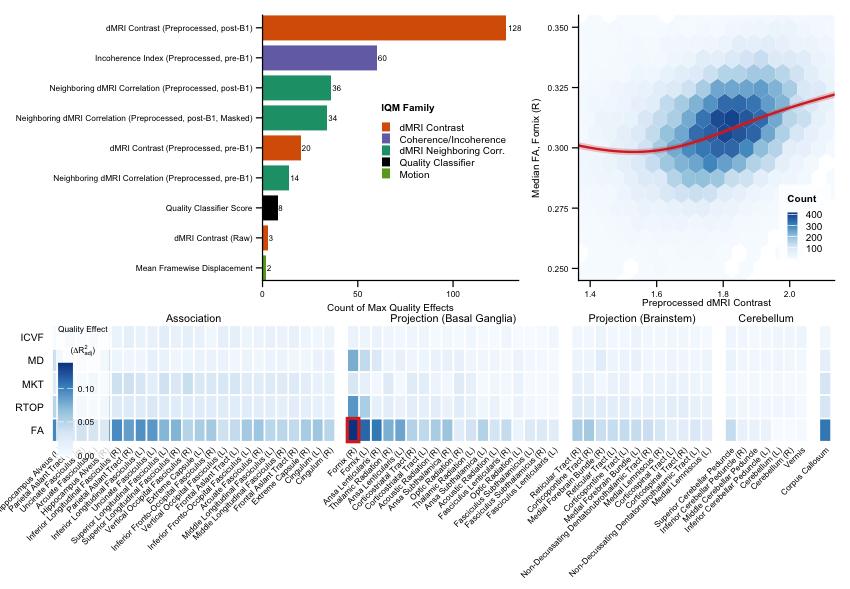

In [ ]:
# For each QC covariate: build heatmap data, identify max-effect cell, Panel B (GAMM scatter), Panel C (heatmap), combine and save
for (qc_target in qc_targets) {
  qc_title <- unname(qc_target_titles[[qc_target]])
  # Filter to this QC; order bundles; get bundle–metric cell with largest QC effect (for Panel B/C focus)
  df_heat <- df_qc_all %>%
    filter(iqm == qc_target) %>%
    mutate(
      metric_label = dplyr::coalesce(unname(metric_labels[as.character(metric)]), as.character(metric)),
      bundle_category_raw = bundle_category,
      bundle_category_pretty = case_when(
        bundle_category == "ProjectionBasalGanglia" ~ "Projection (Basal Ganglia)",
        bundle_category == "ProjectionBrainstem" ~ "Projection (Brainstem)",
        bundle_category == "Commissure" ~ "Corpus Callosum",
        TRUE ~ bundle_category
      ),
      bundle_clean = dplyr::coalesce(prettify_bundle(as.character(bundle)), as.character(bundle))
    )
  if (nrow(df_heat) == 0) {
    stop("No pooled heatmap rows for qc metric: ", qc_target)
  }
  metric_order_heat <- df_heat %>%
    group_by(metric_label) %>%
    summarise(mean_effect = mean(qc_effect_size, na.rm = TRUE), .groups = "drop") %>%
    arrange(desc(mean_effect)) %>%
    pull(metric_label)
  df_heat <- df_heat %>%
    mutate(
      metric_label = factor(metric_label, levels = metric_order_heat),
      bundle_category_pretty = factor(bundle_category_pretty, levels = category_order)
    )
  bundle_df <- df_heat %>%
    group_by(bundle_category_pretty, bundle_category_raw, bundle_clean, bundle) %>%
    summarise(mean_effect = mean(qc_effect_size, na.rm = TRUE), .groups = "drop") %>%
    arrange(bundle_category_pretty, desc(mean_effect), bundle_clean)
  bundle_levels <- c()
  for (cat in category_order) {
    cat_bundles <- bundle_df %>% filter(bundle_category_pretty == cat) %>% pull(bundle_clean)
    if (length(cat_bundles) > 0) {
      bundle_levels <- c(bundle_levels, cat_bundles, paste0("spacer_", cat))
    }
  }
  bundle_levels <- bundle_levels[!grepl("^spacer_Corpus Callosum$", bundle_levels)]
  if (length(bundle_levels) == 0) {
    stop("No bundle levels for qc metric: ", qc_target)
  }
  df_heat <- df_heat %>%
    mutate(bundle_clean = factor(bundle_clean, levels = bundle_levels))
  highlight_cell <- df_heat %>%
    arrange(desc(qc_effect_size)) %>%
    slice(1) %>%
    select(
      bundle_clean, metric_label, metric, bundle,
      bundle_category_raw, bundle_category_pretty, qc_effect_size
    )
  if (nrow(highlight_cell) != 1) {
    stop("Could not identify a unique max quality-effect heatmap cell for ", qc_target)
  }
  highlight_metric <- as.character(highlight_cell$metric[[1]])
  highlight_metric_label <- as.character(highlight_cell$metric_label[[1]])
  highlight_bundle <- as.character(highlight_cell$bundle[[1]])
  highlight_bundle_category_raw <- as.character(highlight_cell$bundle_category_raw[[1]])
  highlight_bundle_clean <- as.character(highlight_cell$bundle_clean[[1]])
  highlight_qc_effect <- as.numeric(highlight_cell$qc_effect_size[[1]])
  message(
    "[INFO] Figure6 max QC effect for ", qc_target,
    ": metric=", highlight_metric,
    " | bundle=", highlight_bundle,
    " | category=", highlight_bundle_category_raw,
    " | qc_effect_size=", signif(highlight_qc_effect, 4)
  )
  # Panel B: QC-vs-bundle scatter from GAMM fit (cached)
  harm_path <- fs::path(project_root, "data", "harmonized_data", "merged_data_meisler_analyses_harmonized.parquet")
  if (!file_exists(harm_path)) stop("Missing harmonized parquet: ", harm_path)
  harm_cols <- arrow::open_dataset(harm_path, format = "parquet")$schema$names
  bundle_col <- paste0(
    "bundle_",
    highlight_bundle_category_raw,
    "_",
    highlight_bundle,
    "_",
    highlight_metric,
    "_median"
  )
  if (!bundle_col %in% harm_cols) {
    fallback_hits <- harm_cols[str_detect(harm_cols, fixed(paste0("_", highlight_bundle, "_", highlight_metric, "_median")))]
    if (length(fallback_hits) == 0) {
      stop("Could not locate panel B bundle column: ", bundle_col)
    }
    bundle_col <- fallback_hits[1]
    message("[WARN] Using fallback panel B bundle column: ", bundle_col)
  }
  panel_b_cache_file <- fs::path(figure6_dir, paste0("Figure6_", qc_target, "_panel_b_qc_scatter_cache.rds"))
  panel_b_cache_key <- list(
    qc_metric = qc_target,
    metric = highlight_metric,
    bundle = highlight_bundle,
    bundle_category = highlight_bundle_category_raw,
    bundle_col = bundle_col,
    harmonized_mtime = as.character(file.info(harm_path)$mtime),
    panel_b_covar = "batch"
  )
  df_panel_b <- NULL
  curve_df <- NULL
  cache_used <- FALSE
  if (file_exists(panel_b_cache_file)) {
    cache_obj <- tryCatch(readRDS(panel_b_cache_file), error = function(e) NULL)
    if (
      is.list(cache_obj) &&
      identical(cache_obj$key, panel_b_cache_key) &&
      is.data.frame(cache_obj$df_panel_b) &&
      is.data.frame(cache_obj$curve_df)
    ) {
      df_panel_b <- cache_obj$df_panel_b
      curve_df <- cache_obj$curve_df
      cache_used <- TRUE
      message("[INFO] Loaded panel B cache: ", panel_b_cache_file)
    } else {
      message("[INFO] Panel B cache exists but key/data mismatch; recomputing.")
    }
  }
  fit_gamm_with_fallback <- function(formula, data) {
    m <- tryCatch(
      gamm4::gamm4(formula = formula, random = ~(1 + age | subject_id), data = data),
      error = function(e) NULL
    )
    if (is.null(m)) {
      m <- tryCatch(
        gamm4::gamm4(formula = formula, random = ~(1 | subject_id), data = data),
        error = function(e) NULL
      )
    }
    m
  }
  if (!cache_used) {
    df_panel_b <- arrow::read_parquet(
      harm_path,
      col_select = all_of(c("subject_id", "batch_device_software", "sex", "age", qc_target, bundle_col))
    ) %>%
      as_tibble() %>%
      transmute(
        subject_id = factor(subject_id),
        batch_device_software = factor(batch_device_software),
        sex = factor(sex),
        age = as.numeric(age),
        qc_var = as.numeric(.data[[qc_target]]),
        value = as.numeric(.data[[bundle_col]])
      ) %>%
      filter(!is.na(value), !is.na(qc_var), !is.na(age), !is.na(batch_device_software), !is.na(sex), !is.na(subject_id))
    if (nrow(df_panel_b) < 100) {
      stop("Insufficient rows for Figure6 panel B GAMM (n < 100) for qc=", qc_target)
    }
    if (!requireNamespace("gamm4", quietly = TRUE)) {
      stop("Figure6 panel B requires package 'gamm4'.")
    }
    full_mod <- fit_gamm_with_fallback(
      value ~ s(age, k = 4) + sex + s(qc_var, k = 4) + batch_device_software,
      data = df_panel_b
    )
    if (is.null(full_mod)) {
      stop("Figure6 panel B GAMM fit failed for qc=", qc_target)
    }
    qc_grid <- seq(
      quantile(df_panel_b$qc_var, 0.01, na.rm = TRUE),
      quantile(df_panel_b$qc_var, 0.99, na.rm = TRUE),
      length.out = 220
    )
    ref_age <- median(df_panel_b$age, na.rm = TRUE)
    ref_sex <- names(sort(table(df_panel_b$sex), decreasing = TRUE))[1]
    ref_batch <- names(sort(table(df_panel_b$batch_device_software), decreasing = TRUE))[1]
    pred_grid <- tibble(
      qc_var = qc_grid,
      age = ref_age,
      sex = factor(ref_sex, levels = levels(df_panel_b$sex)),
      batch_device_software = factor(ref_batch, levels = levels(df_panel_b$batch_device_software))
    )
    pred <- predict(full_mod$gam, newdata = pred_grid, se.fit = TRUE)
    curve_df <- pred_grid %>%
      transmute(
        qc_var = qc_var,
        fit = as.numeric(pred$fit),
        lower = fit - 1.96 * as.numeric(pred$se.fit),
        upper = fit + 1.96 * as.numeric(pred$se.fit)
      )
    saveRDS(
      list(
        key = panel_b_cache_key,
        df_panel_b = df_panel_b,
        curve_df = curve_df
      ),
      panel_b_cache_file
    )
    message("[INFO] Saved panel B cache: ", panel_b_cache_file)
  }
  panel_b_ylabel <- paste0("Median ", highlight_metric_label, ", ", highlight_bundle_clean)
  highlight_red <- "#D73027"
  is_right_fornix_fa <- (highlight_metric == "GQI_fa" && (highlight_bundle == "FornixR" | stringr::str_detect(highlight_bundle, "[Rr]ight.*[Ff]ornix|[Ff]ornix.*[Rr]")))
  if (is_right_fornix_fa) {
    panel_b_density_layer <- if (requireNamespace("hexbin", quietly = TRUE)) {
      geom_hex(aes(fill = after_stat(count)), bins = 42, color = NA, alpha = 0.96)
    } else {
      message("[WARN] Package 'hexbin' not found; using square bins for right-fornix panel B.")
      geom_bin_2d(aes(fill = after_stat(count)), bins = 42, color = NA, alpha = 0.96)
    }
    p_panel_b <- ggplot(df_panel_b, aes(x = qc_var, y = value)) +
      panel_b_density_layer +
      scale_fill_gradientn(
        colours = c("#f7fbff", "#deebf7", "#9ecae1", "#4292c6", "#08519c"),
        name = "Count",
        guide = guide_colorbar(barheight = unit(28, "pt"), barwidth = unit(6, "pt"))
      ) +
      geom_ribbon(
        data = curve_df,
        aes(x = qc_var, ymin = lower, ymax = upper),
        inherit.aes = FALSE,
        fill = highlight_red,
        alpha = 0.25
      ) +
      geom_line(
        data = curve_df,
        aes(x = qc_var, y = fit),
        inherit.aes = FALSE,
        color = highlight_red,
        linewidth = 0.66
      ) +
      labs(title = NULL, x = qc_title, y = panel_b_ylabel) +
      coord_cartesian(xlim = c(1.4, 2.1), ylim = c(0.25, 0.35), clip = "on") +
      make_panel_theme(legend_position = "none") +
      theme(
        panel.grid = element_blank(),
        plot.margin = margin(2, 4, 0, 4),
        axis.title.x = element_text(margin = margin(t = 0)),
        legend.position = c(0.985, 0.05),
        legend.justification = c(1, 0),
        legend.background = element_rect(fill = scales::alpha("white", 0.75), color = NA),
        legend.title = element_text(size = 6),
        legend.text = element_text(size = 6),
        legend.key.height = unit(9, "pt"),
        legend.key.width = unit(6, "pt")
      )
  } else {
    panel_b_density_layer <- if (requireNamespace("hexbin", quietly = TRUE)) {
      geom_hex(aes(fill = after_stat(count)), bins = 42, color = NA, alpha = 0.96)
    } else {
      message("[WARN] Package 'hexbin' not found; using square bins for panel B.")
      geom_bin_2d(aes(fill = after_stat(count)), bins = 42, color = NA, alpha = 0.96)
    }
    p_panel_b <- ggplot(df_panel_b, aes(x = qc_var, y = value)) +
      panel_b_density_layer +
      scale_fill_gradientn(
        colours = c("#f7fbff", "#deebf7", "#9ecae1", "#4292c6", "#08519c"),
        name = "Count",
        guide = guide_colorbar(barheight = unit(28, "pt"), barwidth = unit(6, "pt"))
      ) +
      geom_line(data = curve_df, aes(x = qc_var, y = fit), inherit.aes = FALSE, color = highlight_red, linewidth = 0.66) +
      labs(title = NULL, x = qc_title, y = panel_b_ylabel) +
      coord_cartesian(ylim = c(min(df_panel_b$value, na.rm = TRUE), 0.4), clip = "off") +
      make_panel_theme(legend_position = "none") +
      theme(
        panel.grid = element_blank(),
        plot.margin = margin(2, 4, 0, 4),
        axis.title.x = element_text(margin = margin(t = 0)),
        legend.position = c(0.985, 0.05),
        legend.justification = c(1, 0),
        legend.background = element_rect(fill = scales::alpha("white", 0.75), color = NA),
        legend.title = element_text(size = 6),
        legend.text = element_text(size = 6),
        legend.key.height = unit(9, "pt"),
        legend.key.width = unit(6, "pt")
      )
  }
  # Panel C: heatmap with category spacers/labels and red max-effect rectangle
  spacer_df <- expand.grid(
    bundle_clean = bundle_levels[grepl("^spacer_", bundle_levels)],
    metric_label = metric_order_heat,
    KEEP.OUT.ATTRS = FALSE,
    stringsAsFactors = FALSE
  ) %>%
    mutate(
      qc_effect_size = NA_real_,
      bundle_clean = factor(bundle_clean, levels = bundle_levels),
      metric_label = factor(metric_label, levels = metric_order_heat)
    )
  df_heat_plot <- bind_rows(
    df_heat %>% select(bundle_clean, metric_label, qc_effect_size),
    spacer_df
  )
  x_labels <- levels(df_heat_plot$bundle_clean)
  x_labels[grepl("^spacer_", x_labels)] <- ""
  bundle_index_df <- tibble(bundle_clean = bundle_levels, index = seq_along(bundle_levels))
  cat_positions <- bundle_df %>%
    group_by(bundle_category_pretty) %>%
    summarise(
      xmin = min(bundle_index_df$index[bundle_index_df$bundle_clean %in% bundle_clean]),
      xmax = max(bundle_index_df$index[bundle_index_df$bundle_clean %in% bundle_clean]),
      xmid = mean(c(xmin, xmax)),
      .groups = "drop"
    ) %>%
    filter(bundle_category_pretty != "Corpus Callosum")
  heatmap_export_width_in <- figure_width_in
  heatmap_final_width_in <- figure_width_in
  heatmap_tile_height <- 1.00
  p_panel_c <- ggplot(df_heat_plot, aes(x = bundle_clean, y = metric_label, fill = qc_effect_size)) +
    geom_tile(color = "white", linewidth = 0.45, height = heatmap_tile_height) +
    geom_tile(
      data = highlight_cell,
      aes(x = bundle_clean, y = metric_label),
      fill = NA,
      color = "#D73027",
      linewidth = 0.9,
      width = 0.98,
      height = heatmap_tile_height,
      inherit.aes = FALSE
    ) +
    scale_fill_gradientn(
      colours = c("#f7fbff", "#deebf7", "#9ecae1", "#4292c6", "#084594"),
      name = expression(atop("Quality Effect Size", "(" * Delta * R[adj]^2 * ")")),
      na.value = "white"
    ) +
    guides(fill = guide_colorbar(
      barheight = unit(length(metric_order_heat) * heatmap_tile_height * 0.78, "lines"),
      barwidth = unit(0.62, "lines")
    )) +
    scale_x_discrete(labels = x_labels, expand = expansion(add = 0.8)) +
    scale_y_discrete(expand = expansion(mult = c(0, 0))) +
    coord_cartesian(clip = "off") +
    labs(title = NULL, x = NULL, y = NULL) +
    theme_minimal(
      base_family = font_family_use,
      base_size = pt_for_export(6, heatmap_export_width_in, heatmap_final_width_in)
    ) +
    theme(
      panel.grid = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = pt_for_export(5, heatmap_export_width_in, heatmap_final_width_in), color = "black"),
      axis.text.y = element_text(size = pt_for_export(6.2, heatmap_export_width_in, heatmap_final_width_in), color = "black"),
      axis.ticks = element_blank(),
      plot.title = element_blank(),
      plot.margin = margin(44, 14, 6, 58),
      legend.title = element_text(size = pt_for_export(5, heatmap_export_width_in, heatmap_final_width_in), color = "black"),
      legend.text = element_text(size = pt_for_export(5, heatmap_export_width_in, heatmap_final_width_in), color = "black"),
      legend.position = c(0.01, 0.97),
      legend.justification = c(0, 1),
      legend.direction = "vertical",
      legend.margin = margin(1, 1, 1, 1),
      legend.background = element_rect(fill = scales::alpha("white", 0.76), color = NA),
      legend.box.background = element_blank(),
      panel.background = element_rect(fill = plot_style$panel_background_fill, color = NA),
      plot.background = element_rect(fill = plot_style$plot_background_fill, color = NA),
      panel.border = element_blank()
    )
  y_top <- length(metric_order_heat) + 0.82
  for (i in seq_len(nrow(cat_positions))) {
    p_panel_c <- p_panel_c + annotate(
      "text",
      x = cat_positions$xmid[i],
      y = y_top,
      label = as.character(cat_positions$bundle_category_pretty[i]),
      family = font_family_use,
      size = pt_for_export(6.5, heatmap_export_width_in, heatmap_final_width_in) / .pt,
      color = "black"
    )
  }
  top_row <- p_panel_a | p_panel_b
  top_row <- top_row + patchwork::plot_layout(widths = c(1, 1))
  # Assemble: Panel A (from above) + Panel B + Panel C; then save individual panels and combined
  combined <- top_row / patchwork::free(p_panel_c, side = "l") +
    patchwork::plot_layout(heights = c(top_row_height_in, heat_height_in)) +
    theme(plot.margin = margin(0, 0, 0, 0))
  options(repr.plot.width = figure_width_in, repr.plot.height = figure_height_in, repr.plot.res = 120)
  print(combined)
  stub <- paste0("Figure6_", qc_target)
  save_plot_outputs(p_panel_b, paste0(stub, "_panel_b_qc_scatter"), figure6_panels_dir, figure_width_in * 0.44, top_row_height_in)
  save_plot_outputs(p_panel_c, paste0(stub, "_panel_c_quality_heatmap"), figure6_panels_dir, figure_width_in, panel_c_export_height_in)
  save_plot_outputs(combined, paste0(stub, "_combined"), figure6_dir, figure_width_in, figure_height_in)
}
message("[DONE] Figure 6 variants generated for: ", paste(qc_targets, collapse = ", "))


## Panel D: Mean rating vs preprocessed contrast scatter

Manual-rated scans only. Scatter of `mean_rating` vs `t1post_dwi_contrast` (raw values), colored by vendor, with marginal density strip and Pearson correlation annotation.


`geom_smooth()` using formula = 'y ~ x'
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Arial' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Arial' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Arial' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Arial' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Arial' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Arial' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Arial' not found in PostScript font database”
Warning message in grid.Call(

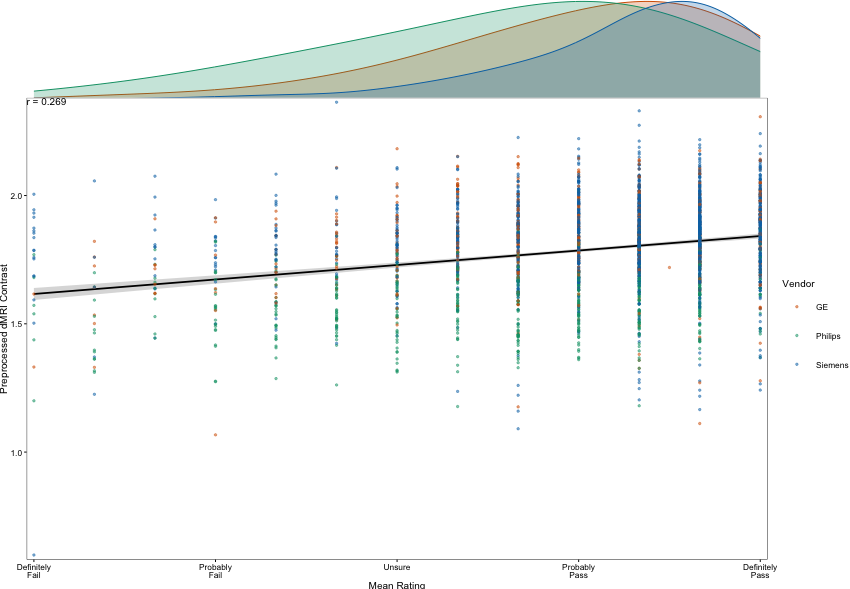

In [4]:
# --- Panel D: Scatter + marginal KDE for manually-rated scans ---

harmonized_path <- fs::path(project_root, "data", "harmonized_data", "merged_data_meisler_analyses_harmonized.parquet")

if (!file.exists(harmonized_path)) {
  message("Harmonized parquet not found; skip Panel D. Path: ", harmonized_path)
} else {
  suppressPackageStartupMessages({
    library(arrow)
    library(cowplot)
  })

  is_manual <- function(x) {
    if (is.logical(x)) return(x %in% TRUE)
    if (is.numeric(x)) return(!is.na(x) & x != 0)
    as.character(x) %in% c("TRUE", "true", "1", "yes")
  }

  df_scatter <- arrow::read_parquet(harmonized_path) %>%
    filter(is_manual(manually_rated)) %>%
    mutate(
      vendor = as.character(scanner_manufacturer),
      mean_rating = suppressWarnings(as.numeric(mean_rating)),
      t1post_dwi_contrast = suppressWarnings(as.numeric(t1post_dwi_contrast))
    ) %>%
    filter(
      vendor %in% c("GE", "Philips", "Siemens"),
      !is.na(mean_rating),
      !is.na(t1post_dwi_contrast)
    ) %>%
    select(vendor, mean_rating, t1post_dwi_contrast)

  if (nrow(df_scatter) == 0) {
    message("No manually-rated scans with both mean_rating and t1post_dwi_contrast; skip Panel D.")
  } else {
    lim_x <- range(df_scatter$mean_rating, na.rm = TRUE)
    lim_y <- range(df_scatter$t1post_dwi_contrast, na.rm = TRUE)
    d_x <- diff(lim_x)
    d_y <- diff(lim_y)
    if (d_x <= 0) d_x <- 1e-6
    if (d_y <= 0) d_y <- 1e-6
    lim_x <- lim_x + c(-0.01, 0.01) * d_x
    lim_y <- lim_y + c(-0.01, 0.01) * d_y

    scatter_width_mm <- 80
    scatter_width_in <- scatter_width_mm / 25.4
    scatter_height_in <- (scatter_width_mm * 4.5 * 25.4 / 180) / 25.4
    pt_scatter <- function(pt) pt_for_export(pt, scatter_width_in, scatter_width_in)

    ct <- cor.test(df_scatter$mean_rating, df_scatter$t1post_dwi_contrast, method = "pearson")
    r_label <- sprintf("r = %.3f", as.numeric(ct$estimate))

    p_main <- ggplot(df_scatter, aes(x = mean_rating, y = t1post_dwi_contrast, color = vendor)) +
      geom_smooth(
        aes(x = mean_rating, y = t1post_dwi_contrast),
        method = "lm",
        se = TRUE,
        color = "black",
        linewidth = 0.5,
        fill = "grey40",
        alpha = 0.25,
        inherit.aes = FALSE,
        data = df_scatter
      ) +
      geom_point(alpha = 0.5, size = 0.5) +
      scale_color_manual(values = vendor_colors, name = "Vendor") +
      scale_x_continuous(
        limits = lim_x,
        breaks = -2:2,
        labels = c("Definitely\nFail", "Probably\nFail", "Unsure", "Probably\nPass", "Definitely\nPass")
      ) +
      scale_y_continuous(limits = lim_y) +
      annotate(
        "text",
        x = lim_x[1],
        y = lim_y[2],
        label = r_label,
        hjust = 0,
        vjust = 1,
        size = 6 / .pt,
        family = font_family_use
      ) +
      labs(x = "Mean Rating", y = "Preprocessed dMRI Contrast") +
      theme_classic(base_family = font_family_use, base_size = pt_scatter(6)) +
      theme(
        panel.grid = element_blank(),
        axis.line = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.25),
        legend.position = "right",
        legend.background = element_rect(fill = scales::alpha("white", 0.95), color = NA),
        plot.margin = margin(0, 0, 0, 0),
        axis.text = element_text(size = pt_scatter(5)),
        axis.title = element_text(size = pt_scatter(6)),
        axis.text.x = element_text(lineheight = 0.8, size = pt_scatter(5)),
        legend.text = element_text(size = pt_scatter(5)),
        legend.title = element_text(size = pt_scatter(6))
      ) +
      coord_cartesian(xlim = lim_x, ylim = lim_y, expand = FALSE)

    strip_ratio <- 0.2
    p_top <- ggplot(df_scatter, aes(x = mean_rating, y = after_stat(ifelse(scaled < 0.015, NA_real_, scaled)), color = vendor, fill = vendor)) +
      geom_density(alpha = 0.25, linewidth = 0.28, adjust = 2.25) +
      scale_color_manual(values = vendor_colors, guide = "none") +
      scale_fill_manual(values = vendor_colors, guide = "none") +
      scale_y_continuous(limits = c(0, 1.02), expand = expansion(mult = c(0, 0)), labels = NULL, breaks = NULL) +
      coord_cartesian(xlim = lim_x, expand = FALSE) +
      theme_void(base_family = font_family_use) +
      theme(plot.margin = margin(0, 0, -2, 0))

    al <- cowplot::align_plots(p_top, p_main, align = "v", axis = "lr")
    top_row <- cowplot::plot_grid(al[[1]], nrow = 1)
    bottom_row <- cowplot::plot_grid(al[[2]], nrow = 1)
    p_panel_d <- cowplot::plot_grid(
      top_row,
      bottom_row,
      ncol = 1,
      align = "v",
      axis = "lr",
      rel_heights = c(strip_ratio, 1)
    )

    save_plot_outputs(
      p_panel_d,
      "Figure6_panel_d_manual_rating_scatter_mean_rating_vs_contrast_marginals",
      figure6_panels_dir,
      scatter_width_in,
      scatter_height_in
    )
    message("[SAVED] Panel D scatter: Figure6_panel_d_manual_rating_scatter_mean_rating_vs_contrast_marginals.pdf and .png (n = ", nrow(df_scatter), " scans)")
    print(p_panel_d)
  }
}


## Panel E: Pooled contrast vs mean-rating violin

Pooled manual-rated quality effects only. Violin of `t1post_dwi_contrast - mean_rating` quality-effect size (`ΔR²_adj`) by metric, with bundle-category jitter and mean segment.


[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure6/panels/Figure6_panel_e_contrast_vs_mean_rating_violin_pooled.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure6/panels/Figure6_panel_e_contrast_vs_mean_rating_violin_pooled.png

[SAVED] Panel E violin: Figure6_panel_e_contrast_vs_mean_rating_violin_pooled.pdf and .png



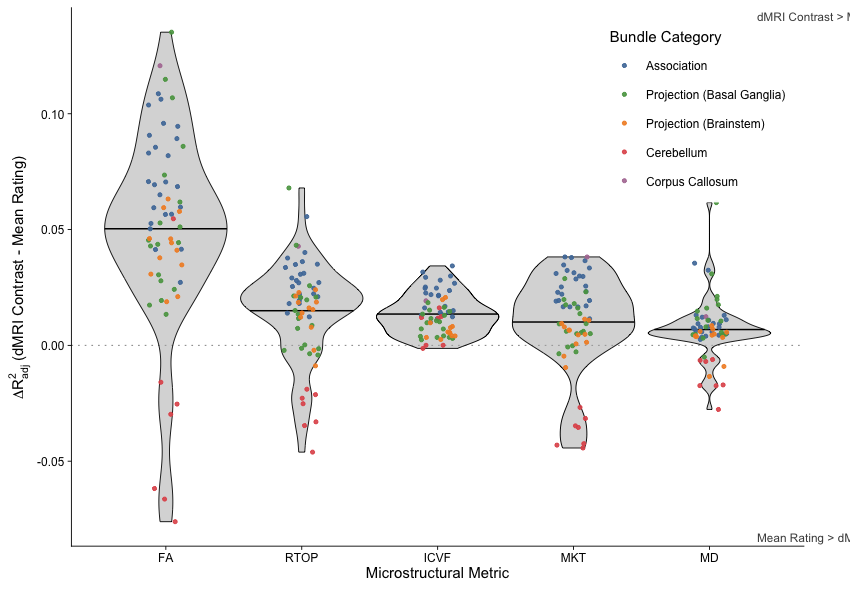

In [5]:
# --- Panel E: Contrast - Mean Rating violin (pooled manual-rated quality effects) ---

manual_qc_rds <- fs::path(project_root, "data", "quality_effects", "quality_effects_manual_rated_all_outputs.rds")

if (!file.exists(manual_qc_rds)) {
  message("Manual-rated quality-effects RDS not found; skip Panel E. Path: ", manual_qc_rds)
} else {
  df_manual <- readRDS(manual_qc_rds) %>%
    filter(
      metric %in% metrics_keep,
      subset == "manual_rated",
      qc_metric %in% c("t1post_dwi_contrast", "mean_rating")
    ) %>%
    mutate(
      metric_label = factor(unname(metric_labels[as.character(metric)]), levels = metric_order),
      bundle_category_pretty = case_when(
        bundle_category == "ProjectionBasalGanglia" ~ "Projection (Basal Ganglia)",
        bundle_category == "ProjectionBrainstem" ~ "Projection (Brainstem)",
        bundle_category == "Commissure" ~ "Corpus Callosum",
        TRUE ~ bundle_category
      ),
      vendor = as.character(vendor)
    ) %>%
    select(bundle, bundle_category_pretty, metric, metric_label, vendor, qc_metric, qc_effect_size)

  df_pooled <- df_manual %>%
    filter(vendor == "pooled") %>%
    pivot_wider(names_from = qc_metric, values_from = qc_effect_size) %>%
    mutate(diff_contrast_minus_mean_rating = t1post_dwi_contrast - mean_rating) %>%
    filter(!is.na(diff_contrast_minus_mean_rating))

  if (nrow(df_pooled) == 0) {
    message("No pooled manual-rated rows available for Panel E; skip.")
  } else {
    metric_order_e <- df_pooled %>%
      group_by(metric_label) %>%
      summarise(mean_diff = mean(diff_contrast_minus_mean_rating, na.rm = TRUE), .groups = "drop") %>%
      arrange(desc(mean_diff)) %>%
      pull(metric_label)

    df_pooled <- df_pooled %>%
      mutate(
        metric_label = factor(metric_label, levels = metric_order_e),
        bundle_category_pretty = factor(bundle_category_pretty, levels = category_order_pretty)
      )

    mean_seg <- df_pooled %>%
      group_by(metric_label) %>%
      summarise(mean_diff = mean(diff_contrast_minus_mean_rating, na.rm = TRUE), .groups = "drop") %>%
      mutate(metric_idx = as.numeric(metric_label))

    violin_build <- ggplot_build(
      ggplot(df_pooled, aes(x = as.numeric(metric_label), y = diff_contrast_minus_mean_rating, group = metric_label)) +
        geom_violin(width = 0.90, trim = TRUE, scale = "width")
    )$data[[1]] %>%
      mutate(metric_idx = as.numeric(group))

    mean_seg <- mean_seg %>%
      mutate(
        width_frac = purrr::map2_dbl(metric_idx, mean_diff, function(idx, mean_val) {
          this_geom <- violin_build %>% filter(metric_idx == idx)
          if (nrow(this_geom) == 0) return(0)
          out <- stats::approx(this_geom$y, this_geom$violinwidth, xout = mean_val, rule = 2)$y
          if (!is.finite(out)) 0 else as.numeric(out)
        }),
        half_width = purrr::map_dbl(metric_idx, function(idx) {
          this_geom <- violin_build %>% filter(metric_idx == idx)
          if (nrow(this_geom) == 0) return(0)
          max(this_geom$xmax - this_geom$x, na.rm = TRUE)
        }) * width_frac,
        x_start = metric_idx - half_width,
        x_end = metric_idx + half_width
      )

    violin_width_in <- 180 / 25.4
    violin_height_in <- 3.8

    p_panel_e <- ggplot(df_pooled, aes(x = as.numeric(metric_label), y = diff_contrast_minus_mean_rating)) +
      geom_hline(yintercept = 0, linetype = "dotted", color = "grey60", linewidth = 0.3) +
      geom_violin(
        aes(group = metric_label),
        color = "black",
        linewidth = 0.25,
        width = 0.90,
        trim = TRUE,
        scale = "width",
        fill = scales::alpha("grey70", 0.50)
      ) +
      geom_segment(
        data = mean_seg,
        aes(x = x_start, xend = x_end, y = mean_diff, yend = mean_diff),
        inherit.aes = FALSE,
        color = "black",
        linewidth = 0.42
      ) +
      geom_jitter(aes(color = bundle_category_pretty), width = 0.13, height = 0, size = 0.85, alpha = 0.9) +
      scale_x_continuous(breaks = seq_along(metric_order_e), labels = as.character(metric_order_e)) +
      scale_color_manual(values = bundle_color_pretty, name = "Bundle Category", drop = FALSE) +
      annotate(
        "text",
        x = length(metric_order_e) + 0.35,
        y = Inf,
        label = "dMRI Contrast > Mean Rating",
        hjust = 0,
        vjust = 1.5,
        size = 2.5,
        color = "grey30"
      ) +
      annotate(
        "text",
        x = length(metric_order_e) + 0.35,
        y = -Inf,
        label = "Mean Rating > dMRI Contrast",
        hjust = 0,
        vjust = -0.5,
        size = 2.5,
        color = "grey30"
      ) +
      labs(
        x = "Microstructural Metric",
        y = expression(Delta * R[adj]^2 ~ "(dMRI Contrast - Mean Rating)")
      ) +
      coord_cartesian(clip = "off") +
      theme_classic(base_family = font_family_use, base_size = 9) +
      theme(
        panel.grid = element_blank(),
        axis.line = element_line(linewidth = 0.25, color = "black"),
        axis.ticks = element_line(linewidth = 0.25, color = "black"),
        legend.position = c(0.985, 0.975),
        legend.justification = c(1, 1),
        legend.background = element_rect(fill = scales::alpha("white", 0.95), color = NA),
        plot.title = element_text(hjust = 0.5),
        plot.margin = margin(5, 28, 5, 5)
      ) +
      NULL

    save_plot_outputs(
      p_panel_e,
      "Figure6_panel_e_contrast_vs_mean_rating_violin_pooled",
      figure6_panels_dir,
      violin_width_in,
      violin_height_in
    )
    message("[SAVED] Panel E violin: Figure6_panel_e_contrast_vs_mean_rating_violin_pooled.pdf and .png")
    print(p_panel_e)
  }
}
